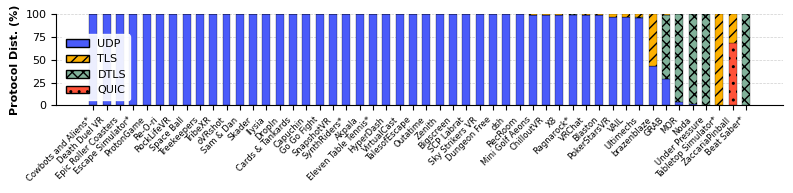

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch
from pathlib import Path
import matplotlib as mpl

# ==========================================
# 1. Global Style Settings (Scaled down for 6x3)
# ==========================================
plt.rcdefaults()
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Liberation Sans', 'DejaVu Sans', 'sans-serif']
plt.rcParams['pdf.fonttype'] = 42

# 6x3 사이즈에 맞게 폰트 크기를 대폭 줄였습니다.
mpl.rcParams.update({
    "font.size": 9,         # 16 -> 9
    "axes.titlesize": 10,   # 18 -> 10
    "axes.labelsize": 8,   # 20 -> 11 (Bold Label용)
    "xtick.labelsize": 6,   # 14 -> 8
    "ytick.labelsize": 8,   # 14 -> 8
    "legend.fontsize": 8,   # 16 -> 8
    "legend.title_fontsize": 9,
})

# ==========================================
# 2. Drive Mount & Data Load
# ==========================================
ROOT = Path('')

if (ROOT / "features_protocol_composition.csv").exists():
    df_enc2 = pd.read_csv(ROOT / "features_protocol_composition.csv")
else:
    # 파일 없을 때 테스트용 더미 데이터
    print("Warning: Using dummy data for testing")
    df_enc2 = pd.DataFrame({
        "App": [f"App_{i}" for i in range(10)],
        "Motion_TOTAL": [1000] * 10,
        "Motion_UDP_PLAIN": np.random.randint(0, 100, 10),
        "Motion_DTLS": np.random.randint(0, 50, 10),
        "Motion_QUIC": np.random.randint(0, 50, 10),
        "Motion_TLS": np.random.randint(0, 50, 10)
    })

df_plot = df_enc2[df_enc2["Motion_TOTAL"] != 0].copy()

# App name cleanup
df_plot["App"] = df_plot["App"].replace({
    "UnityClient@Windows": "Zenith",
    "VAIL-Win64-Shipping": "VAIL",
    "sad": "Sam & Dan",
    "X8SteamClient-Win64-Shipping": "X8",
    "delthisvr-Win64-Shipping": "Mini Golf Aeons",
    "GoGoFight-Win64-Shipping": "Go Go Fight",
    "pong_waves_vr": "Eleven Table Tennis",
    "CowbotsAndAliens": "Cowbots and Aliens",
})
paid_apps = {
    "Cowbots and Aliens",
    "Escape Simulator",
    "SynthRiders",
    "Eleven Table Tennis",
    "Ragnarock",
    "Tabletop Simulator",
    "Beat Saber"
}

# ==========================================
# 3. Data Processing & Sorting
# ==========================================
proto_cols = ["Motion_UDP_PLAIN", "Motion_DTLS", "Motion_QUIC", "Motion_TLS"]

# 1. Calculate Percentages
totals = df_plot[proto_cols].sum(axis=1)
totals_safe = totals.replace(0, np.nan)
pct = df_plot[proto_cols].div(totals_safe, axis=0) * 100
pct = pct.fillna(0)

# 2. Merge & Sort
df_merged = df_plot.join(pct, rsuffix='_pct')

sort_order = [
    "Motion_UDP_PLAIN_pct",
    "Motion_TLS_pct",
    "Motion_QUIC_pct",
    "Motion_DTLS_pct"
]
df_sorted = df_merged.sort_values(by=sort_order, ascending=[False, False, False, False])

# 3. Prepare Plot Data
apps_sorted = [
    a + "*" if a in paid_apps else a
    for a in df_sorted["App"].tolist()
]
pct_sorted = df_sorted[[c + "_pct" for c in proto_cols]].copy()
pct_sorted.columns = proto_cols

# ==========================================
# 4. Plotting (Size 6:3)
# ==========================================
x = np.arange(len(apps_sorted))
w = 0.6  # 막대 너비를 조금 키워서 꽉 차게 보이도록 조정 (0.5 -> 0.6)

# --- Figure Size Change Here ---
plt.figure(figsize=(8, 2))

UDP_COLOR  = "#4A5BFA"
TLS_COLOR  = "#FCB000"
DTLS_COLOR = "#81B29A"
QUIC_COLOR = "#FF5238"

# Print-friendly hatches
UDP_HATCH  = None
TLS_HATCH  = "///"
DTLS_HATCH = "xxx"
QUIC_HATCH = ".."

motion_bottom = np.zeros(len(apps_sorted))

# 1. UDP
plt.bar(x, pct_sorted["Motion_UDP_PLAIN"], width=w,
        color=UDP_COLOR, edgecolor="black", linewidth=0.2, label="UDP", hatch=UDP_HATCH)
motion_bottom += pct_sorted["Motion_UDP_PLAIN"].to_numpy()

# 2. DTLS
plt.bar(x, pct_sorted["Motion_DTLS"], width=w, bottom=motion_bottom,
        color=DTLS_COLOR, edgecolor="black", linewidth=0.2, label="DTLS", hatch=DTLS_HATCH)
motion_bottom += pct_sorted["Motion_DTLS"].to_numpy()

# 3. QUIC
plt.bar(x, pct_sorted["Motion_QUIC"], width=w, bottom=motion_bottom,
        color=QUIC_COLOR, edgecolor="black", linewidth=0.2, label="QUIC", hatch=QUIC_HATCH)
motion_bottom += pct_sorted["Motion_QUIC"].to_numpy()

# 4. TLS
plt.bar(x, pct_sorted["Motion_TLS"], width=w, bottom=motion_bottom,
        color=TLS_COLOR, edgecolor="black", linewidth=0.2, label="TLS", hatch=TLS_HATCH)

# ==========================================
# 5. Styling & Labels
# ==========================================

# X Axis
plt.xticks(x, apps_sorted, rotation=45, ha="right")

# Axis Labels
plt.ylabel("Protocol Dist. (%)", fontweight='bold') # 공간 절약을 위해 줄임말 사용 권장
# plt.xlabel("Applications", fontweight='bold')

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.6)
ax.set_axisbelow(True)
ax.set_ylim(0, 100)

# ==========================================
# 6. Legend
# ==========================================

legend_elems = [
    Patch(facecolor=UDP_COLOR,  edgecolor="black", hatch=UDP_HATCH,  label="UDP"),
    Patch(facecolor=TLS_COLOR,  edgecolor="black", hatch=TLS_HATCH,  label="TLS"),
    Patch(facecolor=DTLS_COLOR, edgecolor="black", hatch=DTLS_HATCH, label="DTLS"),
    Patch(facecolor=QUIC_COLOR, edgecolor="black", hatch=QUIC_HATCH, label="QUIC"),
]
# 범례 위치 및 모양 조정 (작은 그래프에 맞게)
ax.legend(
    handles=legend_elems,
    loc="lower left", # 데이터에 따라 가려질 수 있음. 필요시 "upper right"나 bbox_to_anchor 사용
    frameon=True,
    framealpha=0.9,    # 뒤에 있는 막대가 비치지 않도록 불투명도 추가
    edgecolor='white'
)

# Ensure ylabel fits
plt.subplots_adjust(left=0.09)
plt.tight_layout()

# Save & Show
plt.savefig(
    ROOT / "apps_motion_uplink_protocol_composition_hatch.pdf",
    bbox_inches="tight", dpi=300
)
plt.show()

Saved to: figure1_final_bottom_left_circle.pdf


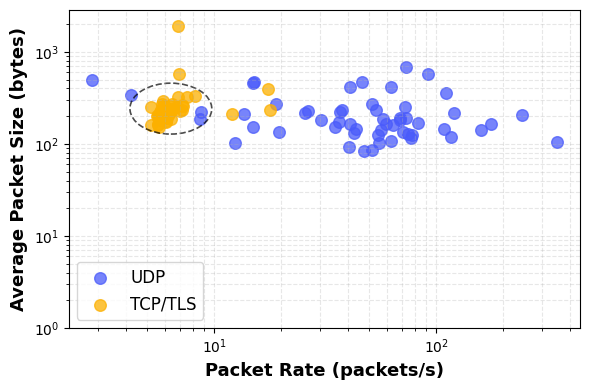

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from matplotlib.patches import Ellipse
from matplotlib.patches import Circle


# ==========================================
# 1. Global Font Settings
# ==========================================
plt.rcdefaults()
plt.rcParams['font.family'] = 'sans-serif'

plt.rcParams['font.sans-serif'] = ['Liberation Sans', 'DejaVu Sans', 'sans-serif']
plt.rcParams['pdf.fonttype'] = 42

# ==========================================
# 2. Drive Mount & Data Load
# ==========================================
ROOT = Path('')

if (ROOT / "features_packet_stats.csv").exists():
    df = pd.read_csv(ROOT / "features_packet_stats.csv")
else:

    df = pd.DataFrame({
        "state": ["MOTION"] * 100,
        "proto": ["UDP"] * 50 + ["TLS"] * 50,
        "pps": 10**np.random.uniform(1, 3, 100),
        "mean_size": 10**np.random.uniform(1, 3, 100)
    })

df_fig = df[
    (df["state"] == "MOTION") &
    (df["proto"].isin(["UDP", "TLS"]))
].copy()

UDP_COLOR = "#4A5BFA"
TLS_COLOR = "#FCB000"

# ==========================================
# 3. Plotting
# ==========================================
fig, ax = plt.subplots(figsize=(6, 4))

for proto, color, label in [
    ("UDP", UDP_COLOR, "UDP"),
    ("TLS", TLS_COLOR, "TCP/TLS")
]:
    sub = df_fig[df_fig["proto"] == proto]
    ax.scatter(sub["pps"], sub["mean_size"],
               s=70, alpha=0.75, color=color, label=label)

# Log Scales
ax.set_xscale("log")
ax.set_yscale("log")

# Y-Axis Limit (Starts from 1)
max_val = df_fig["mean_size"].max() if not df_fig.empty else 1500
ax.set_ylim(1, max_val * 1.5)

# Labels (Bold)
ax.set_xlabel("Packet Rate (packets/s)", fontsize=13, fontweight='bold')
ax.set_ylabel("Average Packet Size (bytes)", fontsize=13, fontweight='bold')

# Grid
ax.grid(True, linestyle="--", alpha=0.3, which='both')


# ==========================================
# Highlight Control-like Traffic (Left cluster) 
# ==========================================
# 중심과 크기는 데이터 분포 보면서 약간씩 조절하면 됨
# x,y,radius 모두 "축 비율 좌표" (0~1)
control_circle = Circle(
    (0.2, 0.69),    # ← 위치 (왼쪽 클러스터 근처, 감으로 조절)
    0.08,           # ← 반지름 (화면 기준)
    transform=ax.transAxes,   # ★ 핵심
    edgecolor="black",
    facecolor="none",
    linewidth=1.2,
    linestyle="--",
    alpha=0.7
)

ax.add_patch(control_circle)


# --- Legend (Bottom Left) ---
ax.legend(frameon=True, fontsize=12, loc='lower left')

plt.tight_layout()
save_path = ROOT / "figure1_final_bottom_left_circle.pdf"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
print(f"Saved to: {save_path}")

plt.show()